In [1]:
from utils.custom_plots import (line_plot,
                                bar_plot, 
                                scatter_plot,
                                ecdf_plot,
                                box_plot,
                                distribution_plot)
from utils.db_utils import run_query
import pandas as pd
import numpy as np

import plotly.io as pio
pio.renderers.default = "png"       # drop this two lines to get local interactive plotly charts

<div class="alert alert-block alert-success">


# **User-centric KPIs**
## **KPIs**
- **Registrations**
- **Active users**
- **Growth**
- **Retention**
### **Benefits**
- Measure **performance** well in **B2Cs**
- Used by investors to **assess** pre-revenue and -profit startups


<div class="alert alert-block alert-success">

## **Registrations** - overview
- Registration: When a user first signs up for an account on Delivr through its app
- Registrations KPI: Counts registrations over time, usually per month
- Good at measuring a company's success in attracting new users
- For Delivr, a user's registration date is the date of that user's first order


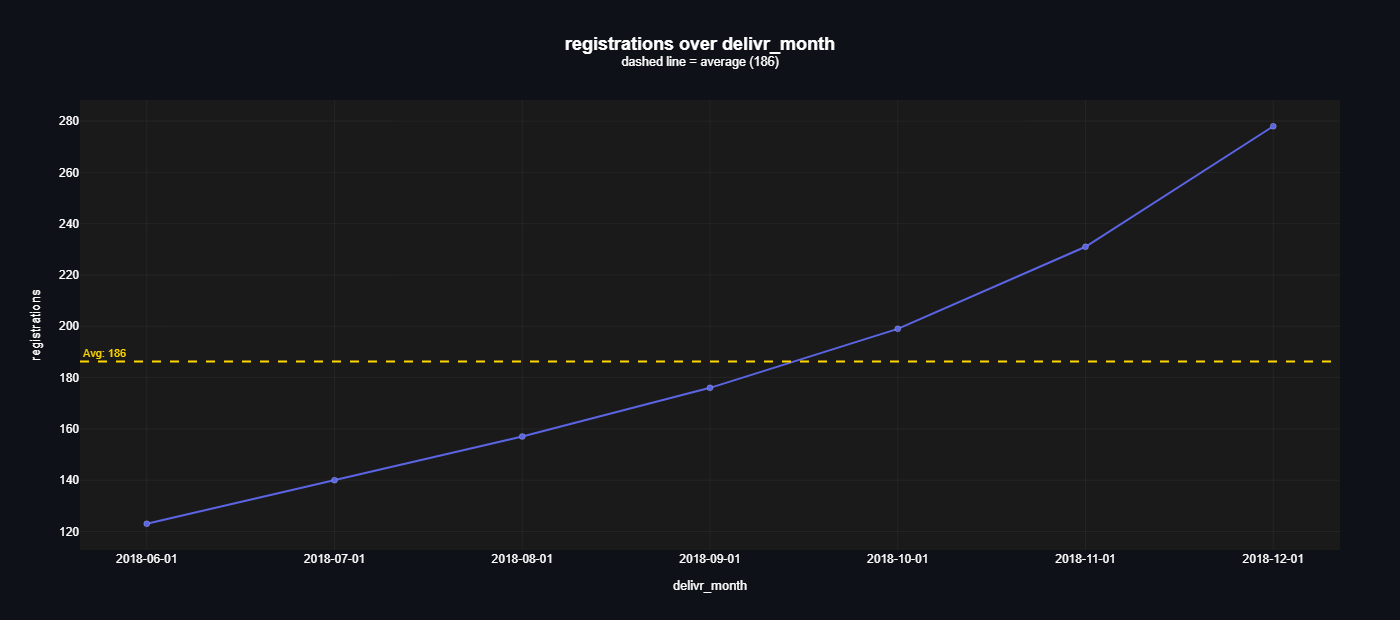

In [2]:
# registration per-month query 

reg_permonth_query = run_query('''
with regs as (
		select
			user_id,
			min(order_date) as reg_date
		from
			orders
		group by
			user_id
	)

select
	date_trunc('month', reg_date)::date as delivr_month,
	count(user_id) as registrations 
	from regs 
	group by delivr_month 
	order by delivr_month;
''')

regs_per_month_lineplot = line_plot(df=reg_permonth_query,
                                    x='delivr_month',
                                    y='registrations',
                                    avg_line=True,
                                    )

regs_per_month_lineplot

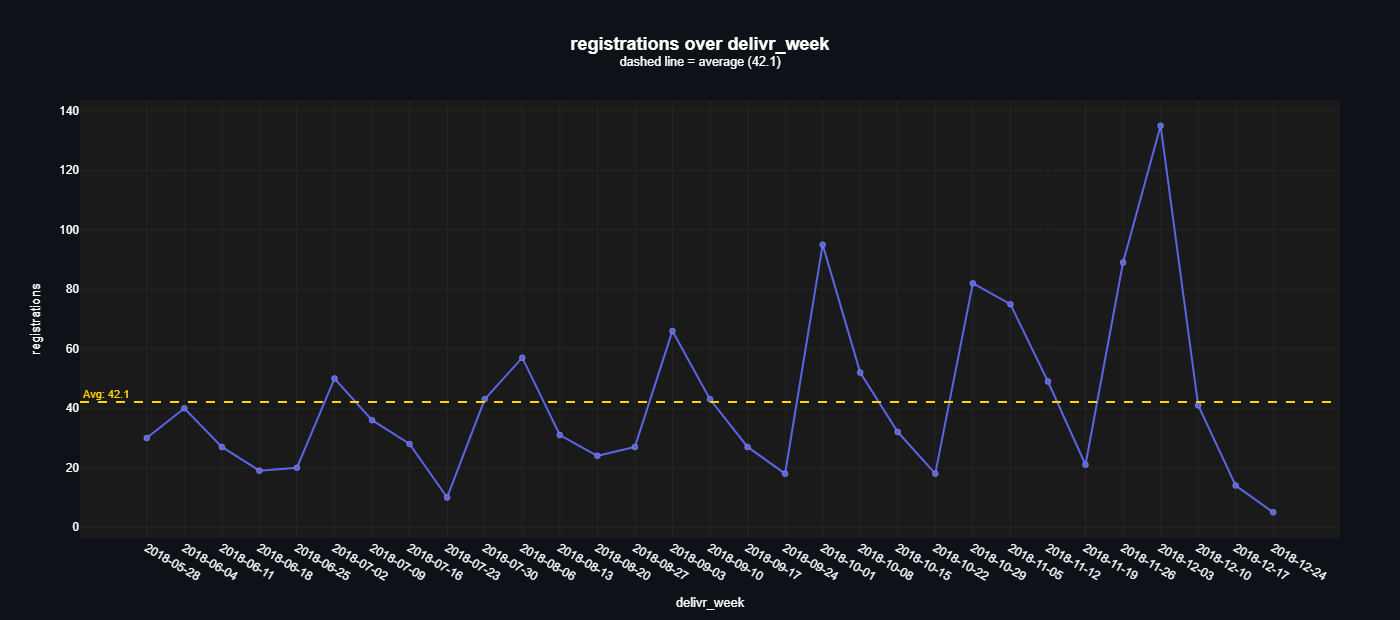

In [3]:
# registrations per week query 

reg_perweek_query = run_query('''
with regs as (
		select
			user_id,
			min(order_date) as reg_date
		from
			orders
		group by
			user_id
	)

select
	date_trunc('week', reg_date)::date as delivr_week,
	count(user_id) as registrations 
	from regs 
	group by delivr_week 
	order by delivr_week;
''')

regs_per_week_lineplot = line_plot(df=reg_perweek_query,
                                    x='delivr_week',
                                    y='registrations',
                                    avg_line=True,
                                    )

regs_per_week_lineplot

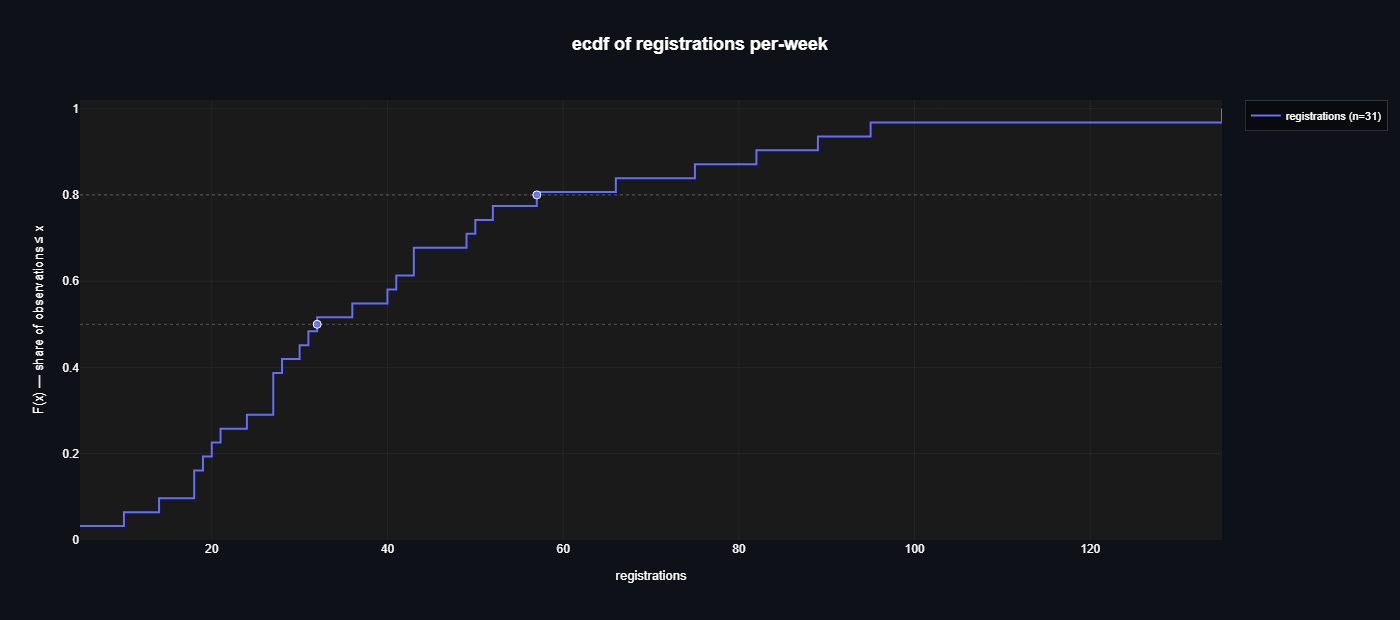

In [4]:
# ecdf plot of registrations per-week

reg_perweek_ecdf_plot = ecdf_plot(df=reg_perweek_query,
                                  cols='registrations',
                                  mark_percentiles=[0.5, 0.8],
                                  title='ecdf of registrations per-week')

reg_perweek_ecdf_plot

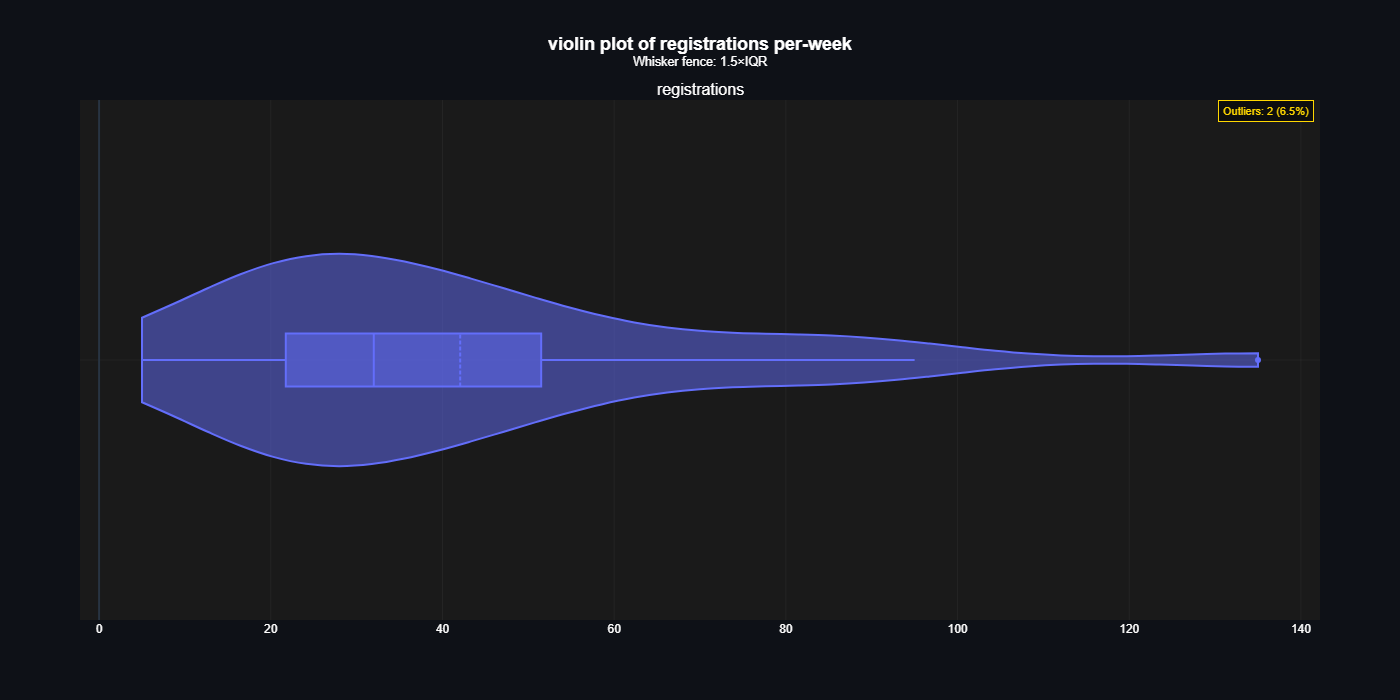

In [10]:
# violin plot of registrations per-week

reg_perweek_violin_plot = box_plot(df=reg_perweek_query,
                                   ignore_cols=['delivr_month'],
                                   kind='violin',
                                   orientation='horizontal',
                                   n_cols=1,
                                   title='violin plot of registrations per-week',
                                   height=700)
reg_perweek_violin_plot

<div class="alert alert-block alert-success">

## **Active users** - overview
- Active users KPI: Counts the active users of a company's app over a time period
- by day (daily active users, or DAU) 
- by month (monthly active users, or MAU)
- Stickiness (DAU / MAU), measures how often users engage with an app on average
- Example: If Delivr's stickiness is DAU / MAU = 0.3 (30%), users use Delivr for $30% x 30$days = 9 days each month on average

In [ ]:
# active users per-month query

mau_query = run_query('''

''')